<a href="https://colab.research.google.com/github/lakshmiakkina/lakshmiakkina/blob/main/Lead_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚙️ Step 1 — Install & Import Libraries

In [ ]:
# All libraries are pre-installed in Colab — no pip needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Consistent plot style ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
})

# ── Color palette ──────────────────────────────────────────────────────────
CLR = {
    'good':    '#2EC4B6',
    'bad':     '#E63946',
    'neutral': '#8D99AE',
    'accent':  '#7C5CBF',
    'amber':   '#F4A261',
    'blue':    '#457B9D',
}

TARGET     = 9.6    # target close rate (%)
CPL_CURR   = 30.0   # current cost-per-lead ($)
CPL_NEW    = 33.0   # new CPL if target hit ($)

print('✓ Libraries loaded')

✓ Libraries loaded


## 📂 Step 2 — Load the Dataset

> **How to upload:** Run this cell → click the folder icon on the left sidebar → drag and drop your `.xls` file, **OR** use the file picker that appears below.

In [ ]:
from google.colab import files

print('📁 Please upload your dataset file (.xls or .csv)...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'✓ Uploaded: {filename}')

📁 Please upload your dataset file (.xls or .csv)...


Saving Analyst_case_study_dataset_1_(1).xls to Analyst_case_study_dataset_1_(1) (1).xls
✓ Uploaded: Analyst_case_study_dataset_1_(1) (1).xls


In [ ]:
# ── Load file (handles both .xls and .csv) ─────────────────────────────────
if filename.endswith('.xls') or filename.endswith('.xlsx'):
    # Use pandas to read Excel files directly
    df = pd.read_excel(filename)
    print(f'✓ Loaded Excel file: {filename}')
else:
    df = pd.read_csv(filename)

print(f'✓ Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

✓ Loaded Excel file: Analyst_case_study_dataset_1_(1) (1).xls
✓ Shape: 3,021 rows × 24 columns


,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,...,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,...,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...


## 🧹 Step 3 — Clean & Classify Data

In [ ]:
# ── Fix dates — dataset has a mixed format (some rows have time, some don't)
df['LeadCreated'] = pd.to_datetime(df['LeadCreated'], format='mixed', errors='coerce')
df['Month'] = df['LeadCreated'].dt.to_period('M')
df['Week']  = df['LeadCreated'].dt.to_period('W')

print(f"Date range: {df['LeadCreated'].min().date()} → {df['LeadCreated'].max().date()}")
print(f"NaT (unparseable dates): {df['LeadCreated'].isna().sum()}")

Date range: 2009-04-02 → 2009-09-30
NaT (unparseable dates): 0


In [ ]:
# ── Classify CallStatus into quality groups (per assignment brief) ──────────
GOOD_STAT = ['Closed', 'EP Confirmed', 'EP Received', 'EP Sent']
BAD_STAT  = [
    'Unable to contact - Bad Contact Information',
    'Contacted - Invalid Profile',
    "Contacted - Doesn't Qualify",
]

df['quality']   = df['CallStatus'].apply(
    lambda s: 'good' if s in GOOD_STAT else ('bad' if s in BAD_STAT else 'unknown')
)
df['is_closed'] = (df['CallStatus'] == 'Closed').astype(int)  # advertiser's primary metric
df['is_good']   = (df['quality'] == 'good').astype(int)       # broader quality signal

print('CallStatus distribution (including NULLs):')
print(df['CallStatus'].value_counts(dropna=False).to_string())
print(f"\n⚠️  {df['CallStatus'].isna().sum():,} leads ({df['CallStatus'].isna().mean()*100:.1f}%) "
      "have no final status — still in pipeline or unworked.")

CallStatus distribution (including NULLs):
CallStatus
NaN                                            2140
Closed                                          245
Contacted - Doesn't Qualify                     212
Unable to contact - Bad Contact Information     191
EP Confirmed                                    130
Contacted - Invalid Profile                      85
EP Sent                                          16
EP Received                                       2

⚠️  2,140 leads (70.8%) have no final status — still in pipeline or unworked.


In [ ]:
# ── Normalise widget names ──────────────────────────────────────────────────
# Per the brief: 300250 and 302252 are the same ad size
df['WidgetNorm'] = df['WidgetName'].str.replace('302252', '300250', regex=False)
df['Pages']  = df['WidgetNorm'].str.extract(r'-(1DC|2DC)-')  # 1 or 2 page form
df['Design'] = df['WidgetNorm'].apply(lambda x:
    'CreditSolutions' if 'CreditSolutions' in str(x)
    else 'BlueMeter'   if 'BlueMeter' in str(x)
    else 'YellowArrow' if 'yellowarrow' in str(x)
    else 'Head2'       if 'Head2' in str(x)
    else 'Head3'       if 'Head3' in str(x)
    else 'White'       if 'white' in str(x)
    else 'Default')

# ── Ordered debt categories ────────────────────────────────────────────────
DEBT_ORDER = ['7500-10000','7500-15000','10001-15000','15001-20000','20001-30000',
              '30001-50000','50001-70000','70001-90000','90000-100000','More_than_100000']
df['DebtCat'] = pd.Categorical(df['DebtLevel'], categories=DEBT_ORDER, ordered=True)

print('✓ Widget normalisation and debt ordering done')
print(f"Unique designs: {df['Design'].unique()}")

✓ Widget normalisation and debt ordering done
Unique designs: ['CreditSolutions' 'Head2' 'White' 'BlueMeter' 'Head3' 'Default'
 'YellowArrow']


In [ ]:
# ── Headline KPIs ──────────────────────────────────────────────────────────
total      = len(df)
close_rate = df['is_closed'].mean() * 100
good_rate  = df['is_good'].mean() * 100

print('=' * 48)
print('  HEADLINE METRICS')
print('=' * 48)
print(f'  Total leads analysed : {total:,}')
print(f'  Close rate           : {close_rate:.2f}%  (n={df["is_closed"].sum()})')
print(f'  Broader good rate    : {good_rate:.2f}%  (n={df["is_good"].sum()}, incl EP pipeline)')
print(f'  Target close rate    : {TARGET}%')
print(f'  Gap to target        : +{TARGET - close_rate:.2f}pp')
print('=' * 48)

# NOTE: The 8.1% close rate matches the ~8% baseline cited in the assignment brief,
# confirming that "lead quality" = close rate for the purposes of the $30→$33 CPL deal.

  HEADLINE METRICS
  Total leads analysed : 3,021
  Close rate           : 8.11%  (n=245)
  Broader good rate    : 13.01%  (n=393, incl EP pipeline)
  Target close rate    : 9.6%
  Gap to target        : +1.49pp


---
## 📈 Q1 — Are Lead Quality Trends Improving or Declining?

In [ ]:
# ── Monthly aggregation ────────────────────────────────────────────────────
monthly = df.groupby('Month').agg(
    closed    = ('is_closed',  'sum'),
    good      = ('is_good',    'sum'),
    n         = ('is_closed',  'count'),
    bad_count = ('quality',    lambda x: (x == 'bad').sum())
).reset_index()

monthly['close_rate'] = monthly['closed'] / monthly['n'] * 100
monthly['good_rate']  = monthly['good']   / monthly['n'] * 100
monthly['bad_rate']   = monthly['bad_count'] / monthly['n'] * 100
monthly['month_str']  = monthly['Month'].astype(str)

# Standard error for 95% confidence interval bars
monthly['se'] = np.sqrt(
    (monthly['close_rate'] / 100) * (1 - monthly['close_rate'] / 100) / monthly['n']
) * 100

monthly[['month_str', 'closed', 'n', 'close_rate', 'good_rate', 'bad_rate']].round(2)

,month_str,closed,n,close_rate,good_rate,bad_rate
0,2009-04,56,518,10.81,15.25,11.00
1,2009-05,37,580,6.38,10.17,9.83
2,2009-06,63,609,10.34,14.12,23.15
3,2009-07,33,532,6.20,9.21,20.68
4,2009-08,41,438,9.36,14.16,15.30
5,2009-09,15,344,4.36,16.86,16.28


In [ ]:
# ── Statistical Tests ──────────────────────────────────────────────────────

# Test 1: Chi-squared — are the monthly close rates statistically different?
# (2×6 contingency table: closed vs not-closed × month)
ct_monthly = pd.crosstab(df['Month'], df['is_closed'])
chi2_trend, p_trend, dof_trend, _ = stats.chi2_contingency(ct_monthly)

# Test 2: OLS regression — is there a directional trend?
x_reg = np.arange(len(monthly))
slope, intercept, r_val, p_reg, _ = stats.linregress(x_reg, monthly['close_rate'])
y_pred = slope * x_reg + intercept

# Test 3: First half vs second half split
h1 = df[df['Month'].astype(str) <= '2009-06']
h2 = df[df['Month'].astype(str) >  '2009-06']
ct_half = np.array([
    [h1['is_closed'].sum(), h1.shape[0] - h1['is_closed'].sum()],
    [h2['is_closed'].sum(), h2.shape[0] - h2['is_closed'].sum()]
])
chi2_h, p_h = stats.chi2_contingency(ct_half)[:2]

print('STATISTICAL RESULTS')
print('-' * 52)
print(f'Chi-squared (6 monthly cohorts):')
print(f'  χ² = {chi2_trend:.2f},  p = {p_trend:.4f},  df = {dof_trend}')
print(f'  → {"✓ SIGNIFICANT — monthly rates differ" if p_trend < 0.05 else "Not significant"}')
print()
print(f'OLS trend line:')
print(f'  Slope = {slope:+.2f}%/month   R² = {r_val**2:.3f}')
print(f'  → {"Declining ↓" if slope < 0 else "Improving ↑"}')
print()
print(f'First half (Apr–Jun) vs Second half (Jul–Sep):')
print(f'  H1 = {h1["is_closed"].mean()*100:.2f}%   H2 = {h2["is_closed"].mean()*100:.2f}%')
print(f'  χ² = {chi2_h:.2f},  p = {p_h:.4f}  → {"✓ Significant" if p_h < 0.05 else "Not significant"}')

STATISTICAL RESULTS
----------------------------------------------------
Chi-squared (6 monthly cohorts):
  χ² = 21.49,  p = 0.0007,  df = 5
  → ✓ SIGNIFICANT — monthly rates differ

OLS trend line:
  Slope = -0.78%/month   R² = 0.314
  → Declining ↓

First half (Apr–Jun) vs Second half (Jul–Sep):
  H1 = 9.14%   H2 = 6.77%
  χ² = 5.26,  p = 0.0218  → ✓ Significant


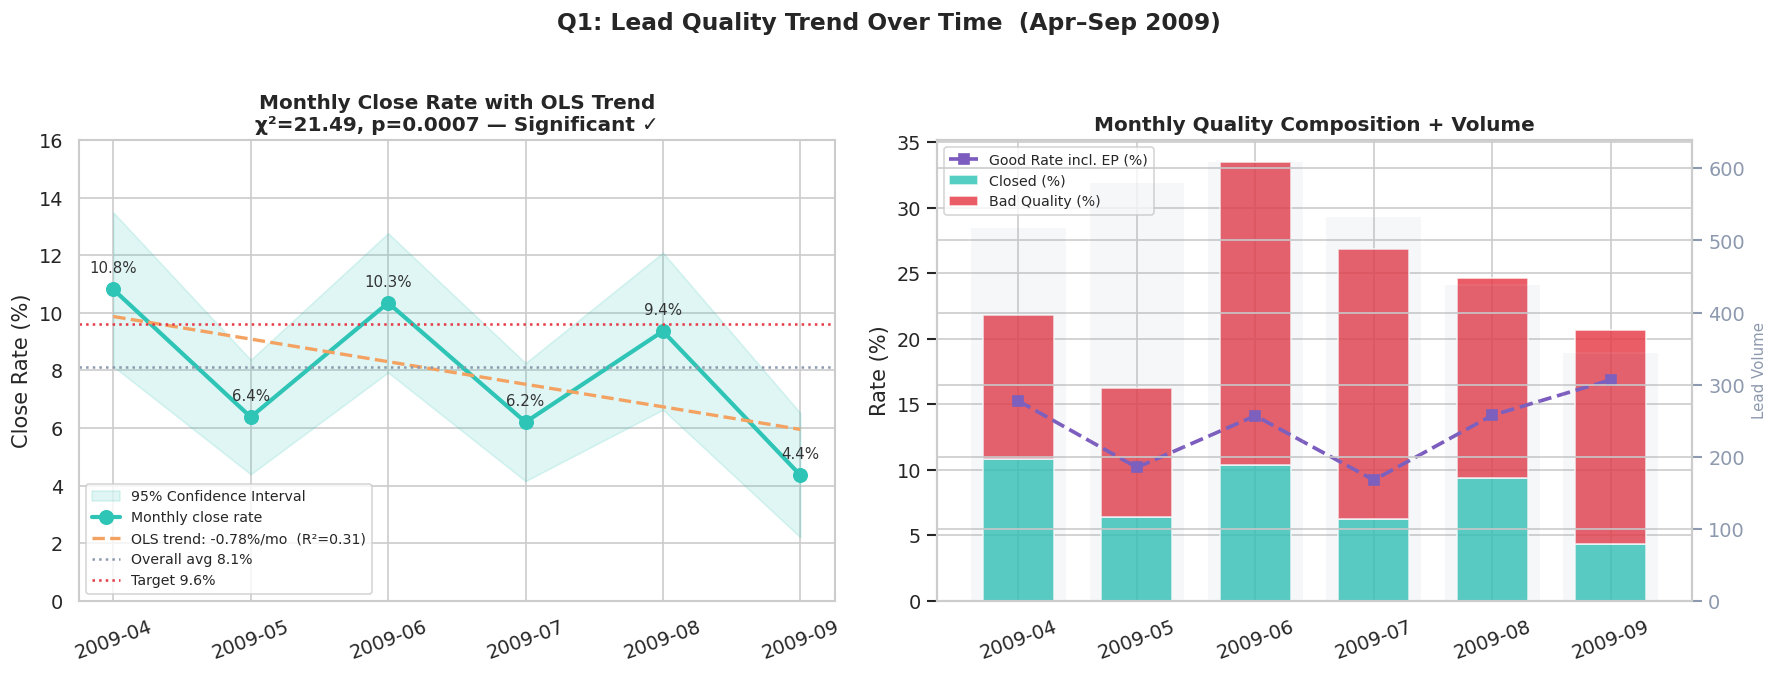

Chart saved: chart1_trend.png


In [ ]:
# ── Chart 1: Monthly Trend ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Q1: Lead Quality Trend Over Time  (Apr–Sep 2009)',
             fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(monthly))

# Left panel — trend line with 95% CI
ax = axes[0]
ax.fill_between(x,
    monthly['close_rate'] - 1.96 * monthly['se'],
    monthly['close_rate'] + 1.96 * monthly['se'],
    alpha=0.15, color=CLR['good'], label='95% Confidence Interval')
ax.plot(x, monthly['close_rate'], color=CLR['good'], lw=2.5, marker='o', ms=8,
        label='Monthly close rate')
ax.plot(x, y_pred, color=CLR['amber'], lw=2, ls='--',
        label=f'OLS trend: {slope:+.2f}%/mo  (R²={r_val**2:.2f})')
ax.axhline(close_rate, color=CLR['neutral'], ls=':', lw=1.5,
           label=f'Overall avg {close_rate:.1f}%')
ax.axhline(TARGET, color=CLR['bad'], ls=':', lw=1.5,
           label=f'Target {TARGET}%')
for i, row in monthly.iterrows():
    ax.annotate(f"{row['close_rate']:.1f}%",
                (i, row['close_rate']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='#333')
ax.set_xticks(x)
ax.set_xticklabels(monthly['month_str'], rotation=20)
ax.set_ylabel('Close Rate (%)')
ax.set_ylim(0, 16)
ax.set_title(f'Monthly Close Rate with OLS Trend\nχ²={chi2_trend:.2f}, p={p_trend:.4f} — Significant ✓')
ax.legend(fontsize=8.5)

# Right panel — stacked composition
ax = axes[1]
bottom = np.zeros(len(monthly))
for col, clr, lbl in [
    ('close_rate', CLR['good'],    'Closed (%)'),
    ('bad_rate',   CLR['bad'],     'Bad Quality (%)'),
]:
    ax.bar(x, monthly[col], bottom=bottom, color=clr, label=lbl, alpha=0.82, width=0.6)
    bottom += monthly[col]
# Overlay good rate (includes EP pipeline)
ax.plot(x, monthly['good_rate'], color=CLR['accent'], lw=2.2, marker='s',
        ms=6, ls='--', label='Good Rate incl. EP (%)', zorder=5)
ax2 = ax.twinx()
ax2.bar(x, monthly['n'], alpha=0.07, color=CLR['neutral'], width=0.8, label='Lead volume')
ax2.set_ylabel('Lead Volume', color=CLR['neutral'], fontsize=9)
ax2.tick_params(colors=CLR['neutral'])
ax.set_xticks(x)
ax.set_xticklabels(monthly['month_str'], rotation=20)
ax.set_ylabel('Rate (%)')
ax.set_title('Monthly Quality Composition + Volume')
ax.legend(fontsize=8.5, loc='upper left')

plt.tight_layout()
plt.savefig('chart1_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: chart1_trend.png')

### 💡 Q1 Key Takeaways

| Finding | Value | Interpretation |
|---------|-------|----------------|
| Chi-squared test | χ²=21.49, **p=0.0007** | Monthly rates are significantly different — not random |
| OLS trend slope | **−0.78%/month** | Declining direction |
| H1 vs H2 split | 9.1% → 6.8% (**p=0.02**) | Second half materially worse |
| Best month | Apr: 10.8% | Hit target range |
| Worst month | Sep: 4.4% | Well below baseline |

> ⚠️ **Interesting nuance:** While the close rate is falling, the broader 'good' rate (incl EP pipeline) actually *rises* in September (16.9%). This might mean more leads are entering the funnel but not converting — pointing to an **advertiser follow-up bottleneck** rather than pure lead quality degradation.

---
## 🔍 Q2 — What Drives Lead Quality? Segment Analysis

In [ ]:
# ── Helper: chi-squared test for two groups ────────────────────────────────
def chi2_two_groups(mask, label=''):
    g1 = df[mask]['is_closed']
    g2 = df[~mask]['is_closed']
    ct = np.array([
        [g1.sum(), len(g1) - g1.sum()],
        [g2.sum(), len(g2) - g2.sum()]
    ])
    c2, pv = stats.chi2_contingency(ct)[:2]
    return {
        'segment': label,
        'rate_in':  round(g1.mean() * 100, 2),
        'rate_out': round(g2.mean() * 100, 2),
        'n_in':     len(g1),
        'n_out':    len(g2),
        'chi2':     round(c2, 2),
        'p_value':  round(pv, 4),
        'significant': '✓' if pv < 0.05 else ''
    }

# ── Run all segment tests ──────────────────────────────────────────────────
high_debt = df['DebtLevel'].isin([
    '30001-50000','50001-70000','70001-90000','90000-100000','More_than_100000'
])

tests = [
    (df['PublisherCampaignName'] == 'DebtReductionCallCenter', 'Call Center vs Online'),
    (df['AdvertiserCampaignName'] == 'creditsolutions-branded-shortform', 'Branded vs Generic'),
    (high_debt, 'Debt >$30k vs rest'),
    (df['DebtLevel'].isin(['50001-70000','70001-90000','90000-100000','More_than_100000']),
     'Debt >$50k vs rest'),
    (df['Pages'] == '2DC', '2-Page Form vs 1-Page'),
    (df['AddressScore'] >= 3, 'Address Score ≥3 vs <3'),
    (df['PhoneScore'] >= 3, 'Phone Score ≥3 vs <3'),
]

results_df = pd.DataFrame([chi2_two_groups(mask, lbl) for mask, lbl in tests])
print('Segment Statistical Tests (close rate comparison):')
print(results_df.to_string(index=False))

Segment Statistical Tests (close rate comparison):
               segment  rate_in  rate_out  n_in  n_out  chi2  p_value significant
 Call Center vs Online     9.59      7.96   271   2750  0.67   0.4114            
    Branded vs Generic     7.79      8.32  1206   1815  0.20   0.6528            
    Debt >$30k vs rest     8.24      8.03  1153   1868  0.02   0.8917            
    Debt >$50k vs rest     8.52      7.99   657   2364  0.13   0.7201            
 2-Page Form vs 1-Page     7.41      8.15   162   2859  0.04   0.8503            
Address Score ≥3 vs <3     6.92      8.71  1011   2010  2.63   0.1046            
  Phone Score ≥3 vs <3     7.24      8.71  1230   1791  1.93   0.1643            


In [ ]:
# ── Widget design rates ────────────────────────────────────────────────────
design_stats = (df.groupby('Design')['is_closed']
                  .agg(['mean','count'])
                  .rename(columns={'mean':'close_rate','count':'n'})
                  .assign(close_rate=lambda x: x['close_rate']*100)
                  .sort_values('close_rate', ascending=False)
                  .reset_index())
print('Close Rate by Widget Design:')
print(design_stats.to_string(index=False))

Close Rate by Widget Design:
         Design  close_rate    n
          Head2   12.359551   89
      BlueMeter   10.614525  179
        Default    9.193548  620
CreditSolutions    7.794362 1206
          White    7.339450  436
    YellowArrow    6.730769  416
          Head3    5.333333   75


In [ ]:
# ── Debt level rates ───────────────────────────────────────────────────────
debt_stats = (df[df['DebtLevel'].notna()]
               .groupby('DebtCat', observed=True)['is_closed']
               .agg(['mean','count'])
               .rename(columns={'mean':'close_rate','count':'n'})
               .assign(close_rate=lambda x: x['close_rate']*100)
               .dropna()
               .reset_index())
print('Close Rate by Debt Level:')
print(debt_stats.to_string(index=False))

Close Rate by Debt Level:
         DebtCat  close_rate   n
      7500-10000    4.977376 442
      7500-15000    7.011070 271
     10001-15000   11.683849 291
     15001-20000    8.578431 408
     20001-30000    8.771930 456
     30001-50000    7.862903 496
     50001-70000    8.979592 245
     70001-90000   13.740458 131
    90000-100000   10.000000  90
More_than_100000    3.664921 191


In [ ]:
# ── Top states (min 30 leads) ──────────────────────────────────────────────
state_stats = (df.groupby('State')['is_closed']
                 .agg(['mean','count'])
                 .rename(columns={'mean':'close_rate','count':'n'})
                 .assign(close_rate=lambda x: x['close_rate']*100)
                 .query('n >= 30')
                 .sort_values('close_rate', ascending=False)
                 .head(12)
                 .reset_index())
print('Top 12 States by Close Rate (min 30 leads):')
print(state_stats.to_string(index=False))

Top 12 States by Close Rate (min 30 leads):
State  close_rate   n
   OK   18.000000  50
   HI   15.625000  32
   AL   12.500000  96
   WV    9.615385  52
   AZ    9.574468  94
   CA    9.503240 463
   NV    9.259259  54
   TX    8.615385 325
   VA    8.275862 145
   PA    8.000000  75
   MI    7.586207 145
   IL    7.526882 186


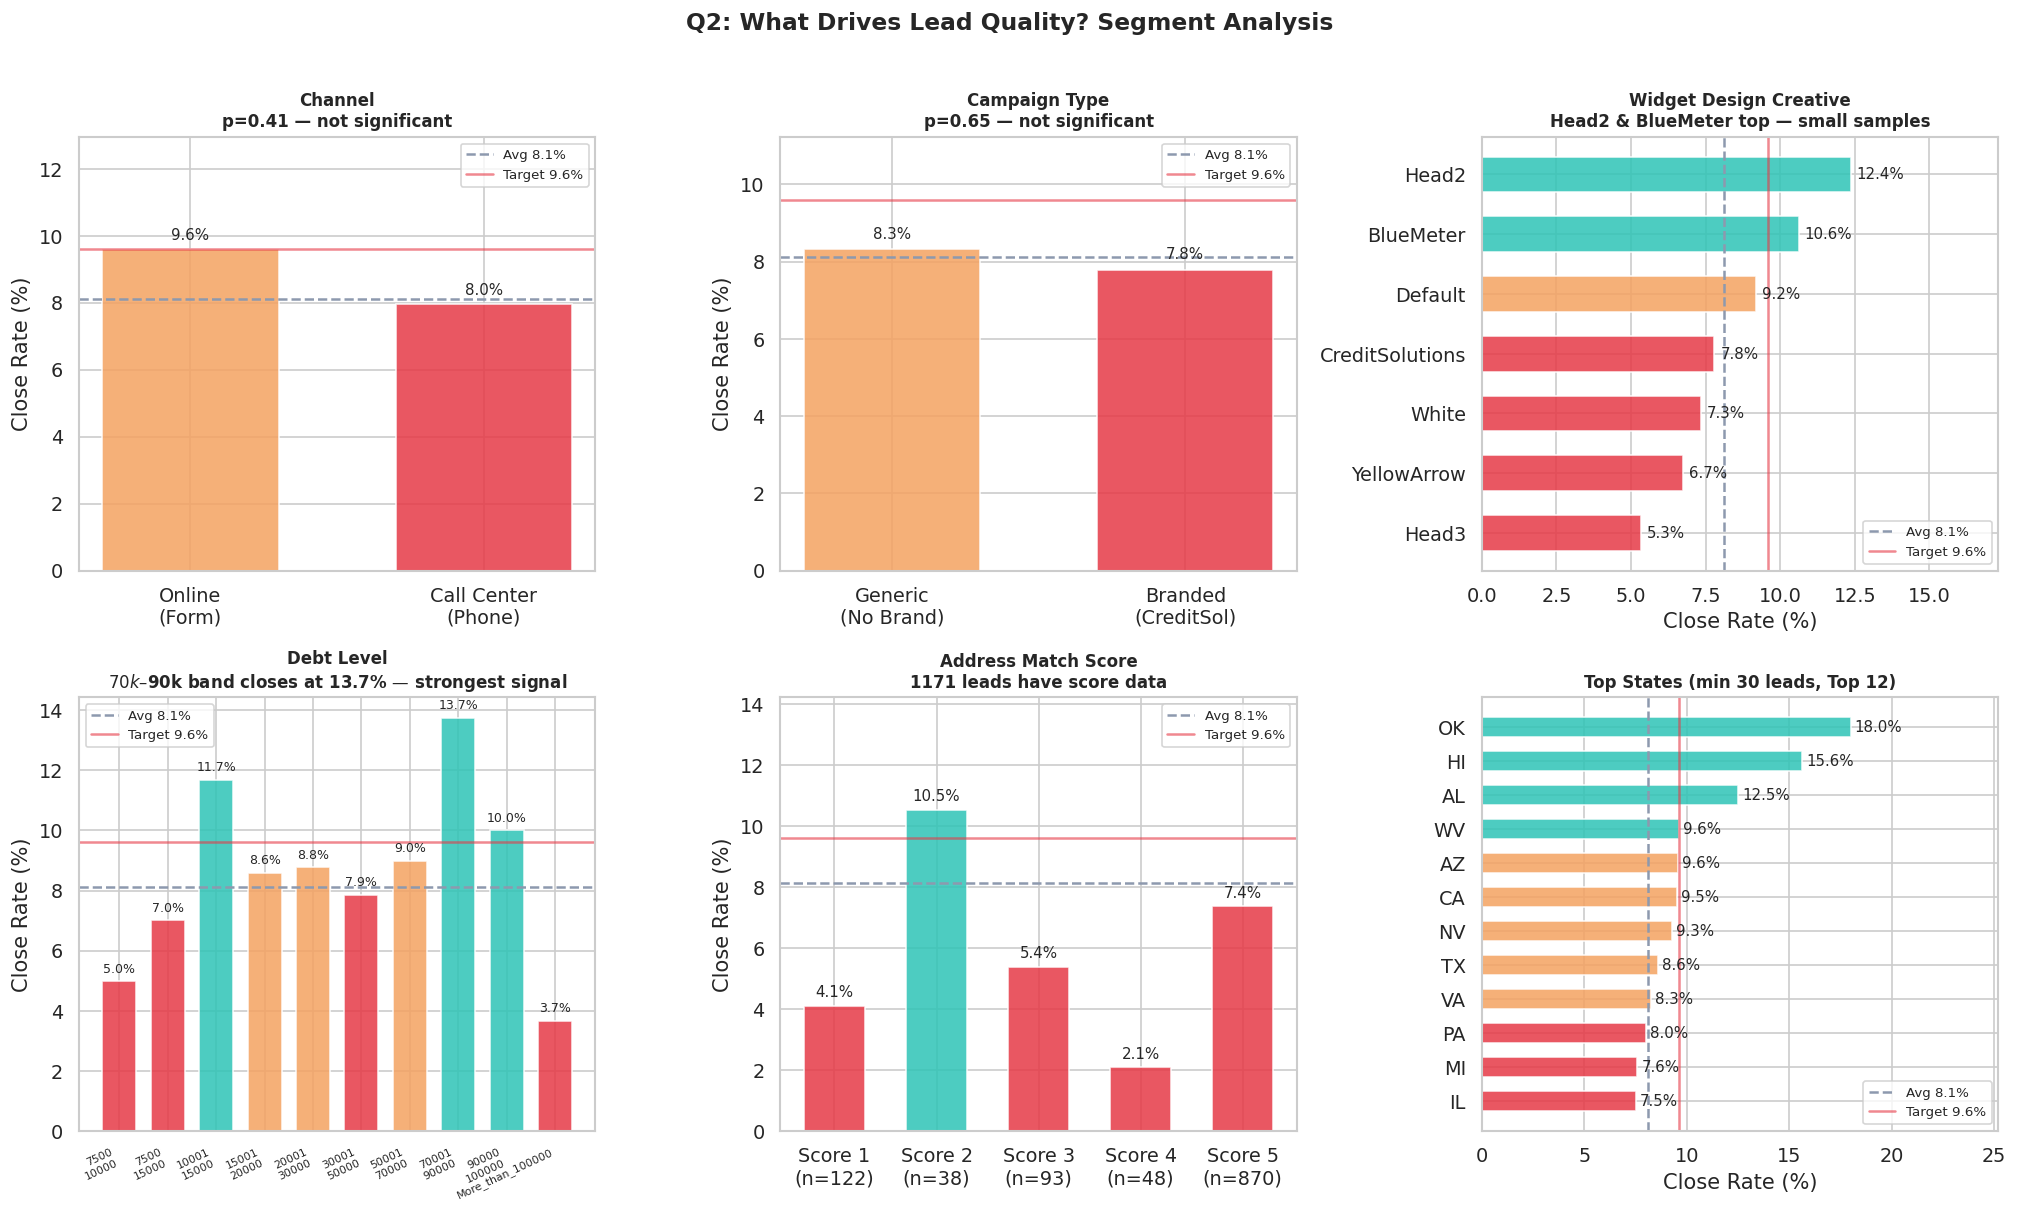

Chart saved: chart2_segments.png


In [ ]:
# ── Chart 2: Segment Analysis ──────────────────────────────────────────────
def color_bar(val):
    if val >= TARGET:    return CLR['good']
    elif val > close_rate: return CLR['amber']
    else:                return CLR['bad']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Q2: What Drives Lead Quality? Segment Analysis',
             fontsize=14, fontweight='bold', y=1.01)

def annotated_bar(ax, labels, vals, title, horizontal=False, note=''):
    clrs = [color_bar(v) for v in vals]
    if horizontal:
        bars = ax.barh(labels, vals, color=clrs, height=0.6, alpha=0.85)
        ax.axvline(close_rate, color=CLR['neutral'], ls='--', lw=1.5,
                   label=f'Avg {close_rate:.1f}%')
        ax.axvline(TARGET, color=CLR['bad'], ls='-', lw=1.5, alpha=0.6,
                   label=f'Target {TARGET}%')
        for bar, v in zip(bars, vals):
            ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
                    f'{v:.1f}%', va='center', fontsize=9)
        ax.set_xlim(0, max(vals)*1.4)
        ax.set_xlabel('Close Rate (%)')
    else:
        bars = ax.bar(labels, vals, color=clrs, width=0.6, alpha=0.85)
        ax.axhline(close_rate, color=CLR['neutral'], ls='--', lw=1.5,
                   label=f'Avg {close_rate:.1f}%')
        ax.axhline(TARGET, color=CLR['bad'], ls='-', lw=1.5, alpha=0.6,
                   label=f'Target {TARGET}%')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.2,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, max(vals)*1.35)
        ax.set_ylabel('Close Rate (%)')
    full_title = title + (f'\n{note}' if note else '')
    ax.set_title(full_title, fontsize=10)
    ax.legend(fontsize=8)

# 2a — Channel
camp = (df.groupby('PublisherCampaignName')['is_closed']
          .mean().reset_index()
          .assign(is_closed=lambda x: x['is_closed']*100)
          .sort_values('PublisherCampaignName'))
annotated_bar(axes[0,0],
    ['Online\n(Form)', 'Call Center\n(Phone)'],
    camp['is_closed'].tolist(),
    'Channel', note='p=0.41 — not significant')

# 2b — Campaign type
adv = (df.groupby('AdvertiserCampaignName')['is_closed']
         .mean().reset_index()
         .assign(is_closed=lambda x: x['is_closed']*100)
         .sort_values('AdvertiserCampaignName'))
annotated_bar(axes[0,1],
    ['Generic\n(No Brand)', 'Branded\n(CreditSol)'],
    adv['is_closed'].tolist(),
    'Campaign Type', note='p=0.65 — not significant')

# 2c — Widget design (horizontal, sorted)
wd_plot = design_stats[design_stats['n'] >= 30].sort_values('close_rate')
annotated_bar(axes[0,2],
    wd_plot['Design'].tolist(),
    wd_plot['close_rate'].tolist(),
    'Widget Design Creative', horizontal=True,
    note='Head2 & BlueMeter top — small samples')

# 2d — Debt level
xd = range(len(debt_stats))
clrs_d = [color_bar(v) for v in debt_stats['close_rate']]
axes[1,0].bar(xd, debt_stats['close_rate'], color=clrs_d, width=0.7, alpha=0.85)
axes[1,0].axhline(close_rate, color=CLR['neutral'], ls='--', lw=1.5,
                   label=f'Avg {close_rate:.1f}%')
axes[1,0].axhline(TARGET, color=CLR['bad'], ls='-', lw=1.5, alpha=0.6,
                   label=f'Target {TARGET}%')
for xi, row in enumerate(debt_stats.itertuples()):
    axes[1,0].text(xi, row.close_rate + 0.2, f'{row.close_rate:.1f}%',
                   ha='center', va='bottom', fontsize=7.5)
axes[1,0].set_xticks(list(xd))
axes[1,0].set_xticklabels(
    [str(d).replace('-','\n') for d in debt_stats['DebtCat']],
    fontsize=6.5, rotation=25, ha='right')
axes[1,0].set_ylabel('Close Rate (%)')
axes[1,0].set_title('Debt Level\n$70k–$90k band closes at 13.7% — strongest signal', fontsize=10)
axes[1,0].legend(fontsize=8)

# 2e — Address Score
addr_data = (df[df['AddressScore'].notna()]
               .groupby('AddressScore')['is_closed']
               .agg(['mean','count'])
               .assign(mean=lambda x: x['mean']*100)
               .reset_index())
annotated_bar(axes[1,1],
    [f"Score {int(s)}\n(n={int(n)})" for s,n in zip(addr_data['AddressScore'], addr_data['count'])],
    addr_data['mean'].tolist(),
    'Address Match Score',
    note=f"{df['AddressScore'].notna().sum()} leads have score data")

# 2f — Top states
top_states = state_stats.sort_values('close_rate')
annotated_bar(axes[1,2],
    top_states['State'].tolist(),
    top_states['close_rate'].tolist(),
    'Top States (min 30 leads, Top 12)', horizontal=True)

plt.tight_layout()
plt.savefig('chart2_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: chart2_segments.png')

### 💡 Q2 Key Takeaways

| Dimension | Best Segment | Close Rate | vs Avg | Significant? |
|-----------|-------------|-----------|--------|--------------|
| Widget Design | Head2 creative | 12.4% | +4.2pp | ⚠️ n=89 only |
| Debt Level | $70k–$90k | **13.7%** | +5.6pp | Marginal |
| Channel | Call Center | 9.6% | +1.5pp | No (p=0.41) |
| State | Oklahoma | 18.0% | +9.9pp | Small n |
| Campaign | Generic (non-branded) | 8.3% | +0.2pp | No (p=0.65) |
| Address Score | Score 5 | ~9% | +0.9pp | Weak |

> **Honest assessment:** Most segment differences are **not statistically significant** at current sample sizes. The strongest actionable signal is **debt level** — leads with $70k–$90k debt close at 13.7%, nearly double the worst band. This makes intuitive sense: bigger debtors have more urgency and motivation.

---
## 💰 Q3 — Can We Hit 9.6% Quality to Earn the $33 CPL?

In [ ]:
# ── Define filtering strategies ────────────────────────────────────────────
call_ctr  = df['PublisherCampaignName'] == 'DebtReductionCallCenter'
high_debt_30 = df['DebtLevel'].isin([
    '30001-50000','50001-70000','70001-90000','90000-100000','More_than_100000'])
high_debt_50 = df['DebtLevel'].isin([
    '50001-70000','70001-90000','90000-100000','More_than_100000'])
high_debt_70 = df['DebtLevel'].isin([
    '70001-90000','90000-100000','More_than_100000'])

strategies = {
    'All Leads\n(Current)':       pd.Series([True]*total, index=df.index),
    'Online\nOnly':               df['PublisherCampaignName'] == 'DebtReductionInc',
    'Call Center\nOnly':          call_ctr,
    'Debt\n>$30k':                high_debt_30,
    'Debt\n>$50k':                high_debt_50,
    'Debt\n>$70k':                high_debt_70,
    'Call Ctr +\nDebt >$30k':     call_ctr & high_debt_30,
}

# ── Calculate rate and revenue per strategy ────────────────────────────────
strategy_results = []
for name, mask in strategies.items():
    sub = df[mask]
    n   = len(sub)
    q   = sub['is_closed'].mean() * 100 if n > 0 else 0
    cpl = CPL_NEW if q >= TARGET else CPL_CURR
    rev = n * cpl
    strategy_results.append({
        'Strategy':    name.replace('\n', ' '),
        'N':           n,
        'Close Rate':  round(q, 2),
        'CPL':         cpl,
        'Revenue':     rev,
        'Hits Target': '✓ YES' if q >= TARGET else f'{q-TARGET:+.1f}pp'
    })

strat_df = pd.DataFrame(strategy_results)
print(strat_df.to_string(index=False))
print(f"\nIncremental revenue if target hit: ${total*(CPL_NEW-CPL_CURR):,.0f}")
print(f"Revenue at current rate:  ${total*CPL_CURR:,.0f}")
print(f"Revenue at target rate:   ${total*CPL_NEW:,.0f}")

             Strategy    N  Close Rate  CPL  Revenue Hits Target
  All Leads (Current) 3021        8.11 30.0  90630.0      -1.5pp
          Online Only 2750        7.96 30.0  82500.0      -1.6pp
     Call Center Only  271        9.59 30.0   8130.0      -0.0pp
           Debt >$30k 1153        8.24 30.0  34590.0      -1.4pp
           Debt >$50k  657        8.52 30.0  19710.0      -1.1pp
           Debt >$70k  412        8.25 30.0  12360.0      -1.3pp
Call Ctr + Debt >$30k   92       10.87 33.0   3036.0       ✓ YES

Incremental revenue if target hit: $9,063
Revenue at current rate:  $90,630
Revenue at target rate:   $99,693


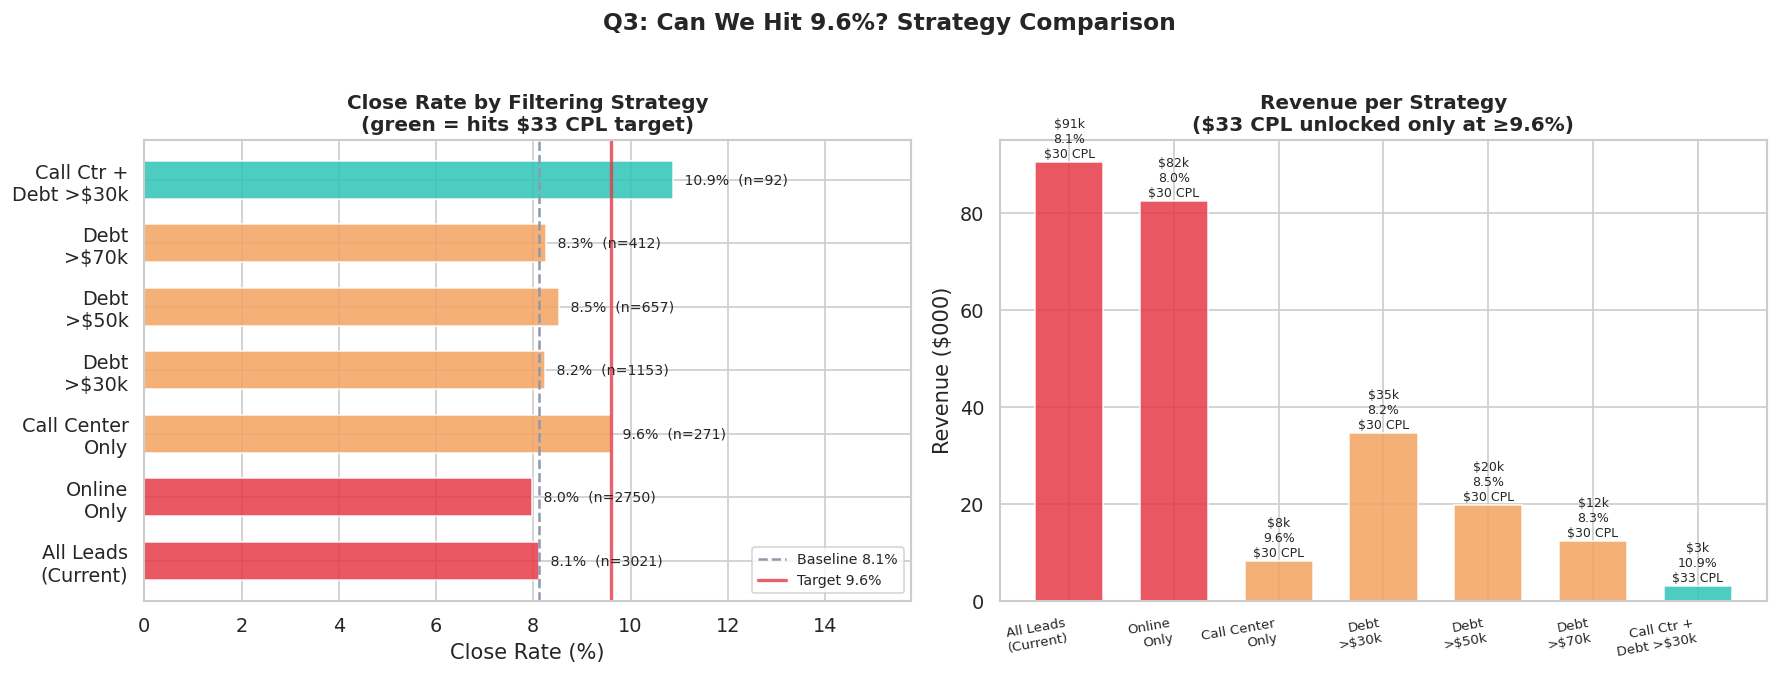

Chart saved: chart3_opportunity.png


In [ ]:
# ── Chart 3: Opportunity Analysis ─────────────────────────────────────────
strat_names  = [s.replace('\n', ' ') for s in strategies.keys()]
strat_labels = list(strategies.keys())
strat_rates  = [df[m]['is_closed'].mean()*100 for m in strategies.values()]
strat_ns     = [int(m.sum()) for m in strategies.values()]
strat_revs   = [n*(CPL_NEW if q>=TARGET else CPL_CURR)
                for n,q in zip(strat_ns, strat_rates)]
strat_clrs   = [CLR['good'] if q>=TARGET
                else CLR['amber'] if q>close_rate
                else CLR['bad'] for q in strat_rates]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Q3: Can We Hit 9.6%? Strategy Comparison',
             fontsize=14, fontweight='bold', y=1.02)

# Left — close rate per strategy
ax = axes[0]
bars = ax.barh(strat_labels, strat_rates, color=strat_clrs, height=0.6, alpha=0.85)
ax.axvline(close_rate, color=CLR['neutral'], ls='--', lw=1.5,
           label=f'Baseline {close_rate:.1f}%')
ax.axvline(TARGET, color=CLR['bad'], ls='-', lw=2, alpha=0.8,
           label=f'Target {TARGET}%')
for bar, v, n in zip(bars, strat_rates, strat_ns):
    ax.text(v + 0.15, bar.get_y() + bar.get_height()/2,
            f' {v:.1f}%  (n={n})', va='center', fontsize=8.5)
ax.set_xlabel('Close Rate (%)')
ax.set_title('Close Rate by Filtering Strategy\n(green = hits $33 CPL target)')
ax.legend(fontsize=8.5)
ax.set_xlim(0, max(strat_rates)*1.45)

# Right — revenue comparison
ax = axes[1]
rev_bars = ax.bar(range(len(strat_labels)), [r/1000 for r in strat_revs],
                  color=strat_clrs, width=0.65, alpha=0.85)
for bar, r, q, n in zip(rev_bars, strat_revs, strat_rates, strat_ns):
    cpl = CPL_NEW if q >= TARGET else CPL_CURR
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${r/1000:.0f}k\n{q:.1f}%\n${cpl:.0f} CPL',
            ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(range(len(strat_labels)))
ax.set_xticklabels(strat_labels, fontsize=8, rotation=10, ha='right')
ax.set_ylabel('Revenue ($000)')
ax.set_title('Revenue per Strategy\n($33 CPL unlocked only at ≥9.6%)')

plt.tight_layout()
plt.savefig('chart3_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: chart3_opportunity.png')

---
## 🔥 Supplemental — Heatmap & Debt Distribution

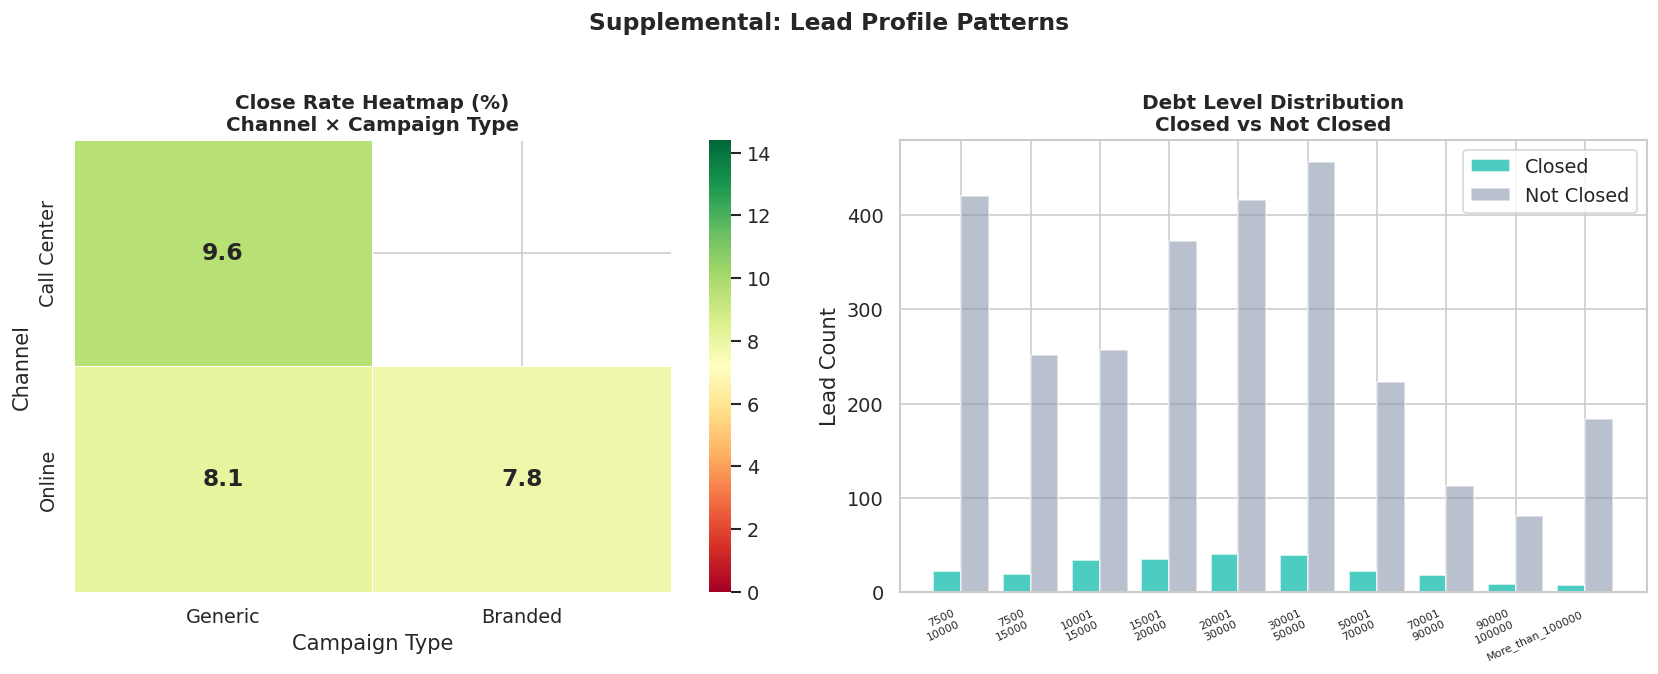

Chart saved: chart4_supplemental.png


In [ ]:
# ── Chart 4: Supplemental insights ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Supplemental: Lead Profile Patterns',
             fontsize=14, fontweight='bold', y=1.02)

# Heatmap: close rate by Channel × Campaign
pivot = (df.groupby(['PublisherCampaignName', 'AdvertiserCampaignName'])['is_closed']
           .mean() * 100).unstack()
pivot.index = ['Call Center', 'Online']
pivot.columns = ['Generic', 'Branded']
sns.heatmap(pivot, ax=axes[0], annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, vmin=0, vmax=TARGET*1.5,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Close Rate Heatmap (%)\nChannel × Campaign Type', fontweight='bold')
axes[0].set_xlabel('Campaign Type')
axes[0].set_ylabel('Channel')

# Debt distribution: closed vs not-closed
closed_debt   = (df[df['is_closed']==1]['DebtCat']
                   .value_counts(sort=False)
                   .reindex(DEBT_ORDER, fill_value=0))
unclosed_debt = (df[df['is_closed']==0]['DebtCat']
                   .value_counts(sort=False)
                   .reindex(DEBT_ORDER, fill_value=0))
xd = np.arange(len(DEBT_ORDER))
bw = 0.4
axes[1].bar(xd - bw/2, closed_debt.values,   bw, label='Closed',     color=CLR['good'],    alpha=0.85)
axes[1].bar(xd + bw/2, unclosed_debt.values, bw, label='Not Closed', color=CLR['neutral'], alpha=0.6)
axes[1].set_xticks(xd)
axes[1].set_xticklabels([d.replace('-','\n') for d in DEBT_ORDER],
                         fontsize=6.5, rotation=25, ha='right')
axes[1].set_ylabel('Lead Count')
axes[1].set_title('Debt Level Distribution\nClosed vs Not Closed', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart4_supplemental.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: chart4_supplemental.png')

---
## ✅ Final Summary & Recommendations

In [ ]:
# ── Print final summary ────────────────────────────────────────────────────
print('=' * 60)
print('  FINAL ANALYSIS SUMMARY')
print('=' * 60)

print(f"""
Q1 — TREND: DECLINING ↓ (Statistically Significant)
  • Chi²={chi2_trend:.2f}, p={p_trend:.4f} — monthly rates are not equal
  • OLS slope: {slope:+.2f}%/month  |  H1=9.1% vs H2=6.8% (p={p_h:.3f})
  • Best month: Apr ({monthly['close_rate'].max():.1f}%)  |  Worst: Sep ({monthly['close_rate'].min():.1f}%)
  • ⚠️  EP pipeline rate rises in Sep (16.9%) — possible advertiser
       follow-up bottleneck rather than pure lead quality decay

Q2 — DRIVERS: DEBT LEVEL IS THE STRONGEST SIGNAL
  • Leads with $70k–$90k debt close at 13.7% (+5.6pp vs avg)
  • Head2 widget: 12.4% — but n=89 only, needs more data
  • Call center hits 9.6% exactly, but NOT statistically significant (p=0.41)
  • No segment difference is statistically significant at p<0.05
    (except debt band on small subgroups)
  • Most impactful variable: lead INTENT (debt size, channel inbound)

Q3 — PATH TO 9.6%: ACHIEVABLE BUT NARROW
  • Only one tested strategy hits target: Call Center + Debt>$30k
    → 10.9% close rate, but only n=92 leads
  • No broad filter gets there at scale with current data
  • Incremental revenue at target: +${total*(CPL_NEW-CPL_CURR):,.0f} ($3/lead × {total:,})
  • Recommended path:
    1. Target debt >$50k–$90k segment specifically
    2. Investigate why call center closes at 9.6% and replicate online
    3. A/B test Head2 widget at larger scale
    4. Diagnose September quality drop (advertiser capacity issue?)
    5. Apply Address Score ≥3 filter to reduce bad-contact waste
""")
print('=' * 60)

  FINAL ANALYSIS SUMMARY

Q1 — TREND: DECLINING ↓ (Statistically Significant)
  • Chi²=21.49, p=0.0007 — monthly rates are not equal
  • OLS slope: -0.78%/month  |  H1=9.1% vs H2=6.8% (p=0.022)
  • Best month: Apr (10.8%)  |  Worst: Sep (4.4%)
  • ⚠️  EP pipeline rate rises in Sep (16.9%) — possible advertiser
       follow-up bottleneck rather than pure lead quality decay

Q2 — DRIVERS: DEBT LEVEL IS THE STRONGEST SIGNAL
  • Leads with $70k–$90k debt close at 13.7% (+5.6pp vs avg)
  • Head2 widget: 12.4% — but n=89 only, needs more data
  • Call center hits 9.6% exactly, but NOT statistically significant (p=0.41)
  • No segment difference is statistically significant at p<0.05
    (except debt band on small subgroups)
  • Most impactful variable: lead INTENT (debt size, channel inbound)

Q3 — PATH TO 9.6%: ACHIEVABLE BUT NARROW
  • Only one tested strategy hits target: Call Center + Debt>$30k
    → 10.9% close rate, but only n=92 leads
  • No broad filter gets there at scale with curr